This example was [contributed by Amadeusz Miszuda](https://github.com/phoebe-project/phoebe2/pull/902#issuecomment-3892950880)

In [1]:
import phoebe
from phoebe.features import ComponentFeature
from phoebe.parameters import FloatParameter, ParameterSet, constraint
from astropy import units as u
import numpy as np

b = phoebe.default_binary()
b.set_value('incl@binary', 80)
b.add_dataset('lc', compute_phases=phoebe.linspace(0,1,101))

class DarkDisk(ComponentFeature):

    allowed_component_kinds = ['star']

    @classmethod
    def create_feature_parameters(cls, feature, **kwargs):

        params = []
        params += [FloatParameter(qualifier='hdisk',
                                  value=kwargs.get('hdisk', 0.0),
                                  default_unit=u.solRad,
                                  description='Thickness of a disk')]

        return ParameterSet(params), []


    @classmethod
    def parse_bundle(cls, b, feature_ps):

        # separation in Rsun
        a = b.get_value('sma', component='binary')

        addl_kw = cls.parse_from_feature_ps(b, feature_ps, [{'qualifier': 'hdisk', 'unit': 'solRad'}])

        return dict(separation=a, **addl_kw)


    def requires_remeshing(self):
        return False


    def modify_intensities(self, abs_normal_intensities, abs_intensities,
                           mus, pblum_scale, extinct_factors, boost_factors,
                           roche_coords, s=[0., 0., 1.], t=None):

        # hdisk in Rsun
        hdisk_rsun = self.kwargs['hdisk']

        # separation in Rsun (from parse_bundle)
        a = self.kwargs['separation']

        # recalculate to Roche units
        hdisk_roche = hdisk_rsun / a

        s = np.array(s)
        s = s / np.linalg.norm(s)

        z_axis = np.dot(roche_coords, s)

        mask = np.abs(z_axis) < hdisk_roche

        abs_normal_intensities[mask] *= 0.01
        abs_intensities[mask] *= 0.01

        return abs_normal_intensities, abs_intensities

b.add_dataset('mesh', compute_phases=phoebe.linspace(0,1,51), columns='intensities*')

b.add_feature(DarkDisk, component='primary', hdisk=0.2, feature='disk', overwrite=True)
b.run_compute(model='with_disk', overwrite=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:02<00:00, 41.90it/s]


<ParameterSet: 515 parameters | kinds: lc, mesh>

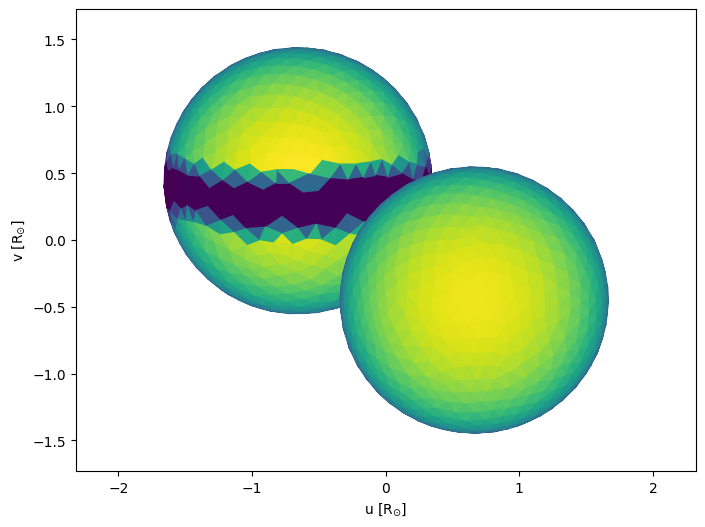

In [3]:
_ = b.plot(kind='mesh', time=0.04, fc='intensities@lc01', ec='face',show=True)